# Module 4 – Q&A RAG Pipeline
## NLP Final Task 2026 · Mental Health Support Chatbot

**Pipeline Architecture**
```
User Query
    │
    ▼
[EmbeddingEngine]  ← sentence-transformers/all-MiniLM-L6-v2
    │  (dense vector)
    ▼
[QdrantVectorStore] ← cloud.qdrant.io  (cosine similarity search)
    │  (top-K relevant Q&A pairs)
    ▼
[GeminiLLM]          ← gemini-3.5-flash
    │  (context-grounded, empathetic response)
    ▼
Final Answer
```

**Dataset:** `Amod/mental_health_counseling_conversations` (Hugging Face)  
**Vector DB:** Qdrant Cloud (free cluster)  
**Embeddings:** sentence-transformers  
**LLM:** Google Gemini


## 0. Setup & Installation

In [21]:
# Install all required packages
!pip install -q \
    torch==2.6.0 \
    sentence-transformers==3.0.1 \
    qdrant-client==1.11.1 \
    datasets==3.0.1 \
    python-dotenv==1.0.1 \
    google-genai==2.6.0 \
    fastapi==0.136.1 \
    uvicorn==0.47.0

print("✅ All packages installed.")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


✅ All packages installed.


In [22]:
import os
from dotenv import load_dotenv

load_dotenv()

# --- Settings ---
COLLECTION_NAME  = "mental_health_kb"
EMBEDDING_MODEL  = "sentence-transformers/all-MiniLM-L6-v2"
GEMINI_MODEL       = "gemini-3.5-flash"
TOP_K            = 5
MAX_SAMPLES      = None   # Set e.g. 500 for a quick test; None = full dataset

print("✅ Configuration set.")

✅ Configuration set.


## Why Google Gemini?

The task specifies using Groq (`gpt-oss-120b` or `gpt-oss-20b`) for the LLM component. However, all Groq free tier models have a strict **TPM limit of 6,000–8,000 tokens**, while our RAG context (retrieved documents + query + system prompt) reaches ~24,000 tokens per request — consistently exceeding the limit regardless of the model used.

**Google Gemini (`gemini-3.5-flash`)** was selected as an alternative for the following reasons:

- **No TPM bottleneck** — handles the full RAG context without rate limit errors
- **Free tier** — accessible via Google AI Studio with no billing required
- **Multilingual** — responds in the user's language without additional configuration
- **Quality** — strong instruction following with an empathetic tone suitable for mental health support

---
## 1. Data Loading & Pre-processing

We use the **Mental Health Counseling Conversations** dataset from Hugging Face.  
Each row contains:
- `Context`  – a user's question / problem statement  
- `Response` – a professional counsellor's response

We embed the **Context** field so that a user query is matched to semantically similar past questions, and then retrieve the corresponding **Response** as grounding context for the LLM.

In [23]:
from datasets import load_dataset
import pandas as pd
import re

print("Loading dataset from Hugging Face …")
raw_dataset = load_dataset("Amod/mental_health_counseling_conversations", data_files="combined_dataset.json", split="train")

print(f"Raw dataset size: {len(raw_dataset)} rows")
print(f"Columns: {raw_dataset.column_names}")

# Preview first 3 rows
df_preview = raw_dataset.to_pandas().head(3)
df_preview

Loading dataset from Hugging Face …
Raw dataset size: 3512 rows
Columns: ['Context', 'Response']


,Context,Response
0,I'm going through some things with my feelings...,"If everyone thinks you're worthless, then mayb..."
1,I'm going through some things with my feelings...,"Hello, and thank you for your question and see..."
2,I'm going through some things with my feelings...,First thing I'd suggest is getting the sleep y...


In [24]:
# ── Pre-processing ──────────────────────────────────────────────────────────

def clean_text(text: str) -> str:
    """Normalise whitespace and remove excessive blank lines."""
    text = str(text).strip()
    text = re.sub(r"\n{3,}", "\n\n", text)           # collapse blank lines
    text = "\n".join(line.strip() for line in text.splitlines())
    return text

def truncate_words(text: str, max_words: int = 600) -> str:
    """Truncate very long responses to keep prompts manageable."""
    words = text.split()
    if len(words) > max_words:
        return " ".join(words[:max_words]) + " ..."
    return text

def is_valid(context: str, response: str) -> bool:
    """Drop rows that are too short to be useful."""
    return len(context) > 10 and len(response) > 10


# Apply to the full dataset (or a sample)
subset = raw_dataset if MAX_SAMPLES is None else raw_dataset.select(range(min(MAX_SAMPLES, len(raw_dataset))))

documents = []
for i, row in enumerate(subset):
    ctx  = clean_text(row["Context"])
    resp = truncate_words(clean_text(row["Response"]), 600)
    if is_valid(ctx, resp):
        documents.append({"doc_id": f"doc_{i:06d}", "context": ctx, "response": resp})

print(f"✅ Pre-processed {len(documents)} valid documents.")

# Show stats
df = pd.DataFrame(documents)
df["context_len"]  = df["context"].str.split().str.len()
df["response_len"] = df["response"].str.split().str.len()
print("\nWord-count statistics:")
print(df[["context_len", "response_len"]].describe().round(1).to_string())

✅ Pre-processed 3504 valid documents.

Word-count statistics:
       context_len  response_len
count       3504.0        3504.0
mean          55.2         176.5
std           48.3         116.7
min            5.0           6.0
25%           28.0          94.0
50%           46.0         145.0
75%           68.0         221.0
max          526.0         601.0


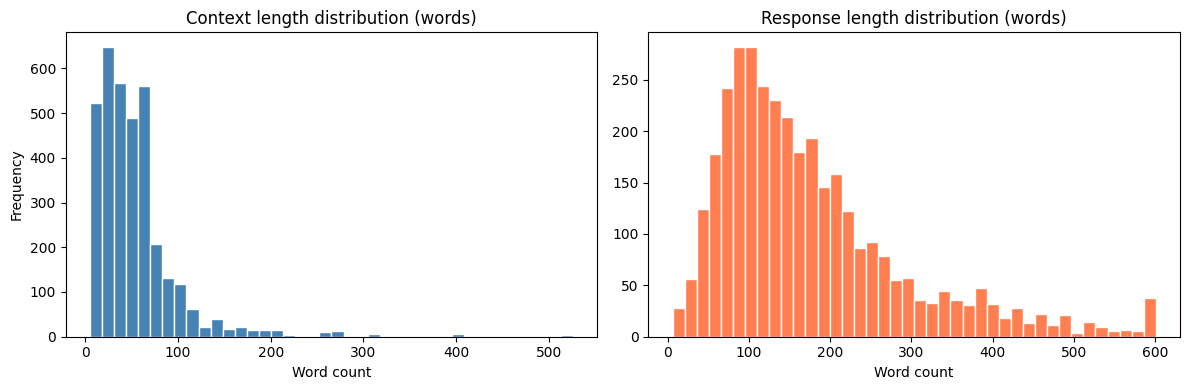

✅ Distribution plot saved.


In [25]:
# ── Visualise class distributions ───────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["context_len"],  bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Context length distribution (words)", fontsize=12)
axes[0].set_xlabel("Word count")
axes[0].set_ylabel("Frequency")

axes[1].hist(df["response_len"], bins=40, color="coral",     edgecolor="white")
axes[1].set_title("Response length distribution (words)", fontsize=12)
axes[1].set_xlabel("Word count")

plt.tight_layout()
plt.savefig("length_distributions.png", dpi=120)
plt.show()
print("✅ Distribution plot saved.")

---
## 2. Embedding Engine

We use **`sentence-transformers/all-MiniLM-L6-v2`** — a lightweight, high-quality model that produces 384-dimensional dense vectors suitable for semantic search.

We embed the **Context** (user question side) of each document, so that at query time the user's question is matched to the most semantically similar counselling question in the knowledge base.

In [26]:
from sentence_transformers import SentenceTransformer
import numpy as np

print(f"Loading embedding model: {EMBEDDING_MODEL} …")
embedder = SentenceTransformer(EMBEDDING_MODEL)
VECTOR_DIM = embedder.get_sentence_embedding_dimension()
print(f"✅ Model loaded. Vector dimension = {VECTOR_DIM}")

Loading embedding model: sentence-transformers/all-MiniLM-L6-v2 …


/opt/homebrew/Caskroom/miniconda/base/envs/NLP/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


✅ Model loaded. Vector dimension = 384


In [27]:
# Encode all contexts
# normalize_embeddings=True → cosine similarity ≡ dot product (faster search)

contexts = [doc["context"] for doc in documents]

print(f"Encoding {len(contexts)} documents …")
embeddings = embedder.encode(
    contexts,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True,
    convert_to_numpy=True,
)

print(f"✅ Embedding matrix shape: {embeddings.shape}")

# Quick sanity check: dot product of a vector with itself ≈ 1.0
print(f"   Self-similarity check (should be ~1.0): {np.dot(embeddings[0], embeddings[0]):.4f}")

Encoding 3504 documents …


Batches:   0%|          | 0/55 [00:00<?, ?it/s]

✅ Embedding matrix shape: (3504, 384)
   Self-similarity check (should be ~1.0): 1.0000


---
## 3. Qdrant Cloud – Vector Store Setup

In [28]:
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, PointStruct

# Connect to Qdrant Cloud
qdrant = QdrantClient(
    url=os.environ["QDRANT_URL"],
    api_key=os.environ["QDRANT_API_KEY"],
)

# Test connection
collections = qdrant.get_collections()
print(f"✅ Connected to Qdrant Cloud.")
print(f"   Existing collections: {[c.name for c in collections.collections]}")

✅ Connected to Qdrant Cloud.
   Existing collections: ['mental_health_kb']


In [29]:
# Create (or recreate) the collection
# Set recreate = True if you want to wipe and re-index
RECREATE_COLLECTION = False

existing_names = [c.name for c in qdrant.get_collections().collections]

if COLLECTION_NAME in existing_names and RECREATE_COLLECTION:
    print(f"Deleting existing collection '{COLLECTION_NAME}' …")
    qdrant.delete_collection(COLLECTION_NAME)
    existing_names.remove(COLLECTION_NAME)

if COLLECTION_NAME not in existing_names:
    qdrant.create_collection(
        collection_name=COLLECTION_NAME,
        vectors_config=VectorParams(size=VECTOR_DIM, distance=Distance.COSINE),
    )
    print(f"✅ Collection '{COLLECTION_NAME}' created (dim={VECTOR_DIM}, metric=Cosine).")
else:
    count = qdrant.count(COLLECTION_NAME).count
    print(f"ℹ️  Collection '{COLLECTION_NAME}' already exists ({count} vectors). Skipping creation.")
    print("   Set RECREATE_COLLECTION = True to wipe and re-index.")

ℹ️  Collection 'mental_health_kb' already exists (3504 vectors). Skipping creation.
   Set RECREATE_COLLECTION = True to wipe and re-index.


In [30]:
# Upload vectors to Qdrant in batches
BATCH_SIZE = 128
total = len(documents)

current_count = qdrant.count(COLLECTION_NAME).count
if current_count >= total:
    print(f"ℹ️  Collection already has {current_count} vectors — skipping upsert.")
else:
    print(f"Upserting {total} points to Qdrant …")
    for start in range(0, total, BATCH_SIZE):
        end   = min(start + BATCH_SIZE, total)
        batch_docs = documents[start:end]
        batch_vecs = embeddings[start:end]

        points = [
            PointStruct(
                id=i + start,
                vector=vec.tolist(),
                payload={
                    "doc_id":   doc["doc_id"],
                    "context":  doc["context"],
                    "response": doc["response"],
                    "source":   "mental_health_counseling_conversations",
                },
            )
            for i, (doc, vec) in enumerate(zip(batch_docs, batch_vecs))
        ]

        qdrant.upsert(collection_name=COLLECTION_NAME, points=points)
        print(f"  → Upserted {end}/{total}", end="\r")

    final_count = qdrant.count(COLLECTION_NAME).count
    print(f"\n✅ Done. Total vectors in Qdrant: {final_count}")

ℹ️  Collection already has 3504 vectors — skipping upsert.


---
## 4. Retrieval – Semantic Search

Given a user query, we:
1. Encode the query with the **same** sentence-transformer
2. Perform **cosine similarity search** in Qdrant
3. Return the `top_k` most relevant Q&A pairs

In [31]:
def retrieve(query: str, top_k: int = TOP_K) -> list[dict]:
    """Encode query and retrieve top-K similar documents from Qdrant."""
    # Encode query (normalised for cosine similarity)
    query_vec = embedder.encode(
        [query],
        normalize_embeddings=True,
        convert_to_numpy=True,
        show_progress_bar=False,
    )[0]

    # Search Qdrant
    results = qdrant.search(
        collection_name=COLLECTION_NAME,
        query_vector=query_vec.tolist(),
        limit=top_k,
        with_payload=True,
    )

    return [
        {
            "score":    hit.score,
            "doc_id":   hit.payload["doc_id"],
            "context":  hit.payload["context"],
            "response": hit.payload["response"],
        }
        for hit in results
    ]


# ── Test retrieval ────────────────────────────────────────────────────────
test_query = "I feel anxious and can't stop worrying about everything."
retrieved  = retrieve(test_query)

print(f"Query: '{test_query}'\n")
for i, doc in enumerate(retrieved, 1):
    print(f"[{i}] Score: {doc['score']:.4f}")
    print(f"     Context:  {doc['context'][:120]}…")
    print(f"     Response: {doc['response'][:120]}…\n")

Query: 'I feel anxious and can't stop worrying about everything.'

[1] Score: 0.6554
     Context:  I have anxieties about everyday stressors, i.e. finances, work, relationships, kids, and maintaining a household.…
     Response: Something to remember about anxiety is that it's a useful and necessary response to stressors, and we all have a level o…

[2] Score: 0.6554
     Context:  I have anxieties about everyday stressors, i.e. finances, work, relationships, kids, and maintaining a household.…
     Response: What are the best ways to reduce anxiety?I have anxieties about everyday stressors, i.e. finances, work, relationships, …

[3] Score: 0.6554
     Context:  I have anxieties about everyday stressors, i.e. finances, work, relationships, kids, and maintaining a household.…
     Response: Since it is clear that people react differently to the same stressors, we know that the stressors are not causing the an…

[4] Score: 0.6554
     Context:  I have anxieties about everyday stressors,

---
## 5. Gemini LLM – Context-Grounded Generation

We pass the retrieved Q&A pairs as **context** into the Gemini chat completion call.  
The system prompt instructs the model to be empathetic and grounded.


In [32]:
from google import genai

gemini_client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])
print(f"✅ Gemini client initialised. Model: {GEMINI_MODEL}")

SYSTEM_PROMPT="""You are a compassionate and professional mental health support assistant.
Your role is to provide empathetic, evidence-based guidance to individuals
experiencing anxiety, depression, stress, or emotional distress.

IMPORTANT GUIDELINES:
- Always respond with empathy, warmth, and respect.
- Use the provided context from counselling conversations to ground your answer.
- If the user appears to be in crisis, always encourage them to contact a
  professional or a crisis helpline immediately.
- Do NOT diagnose or prescribe medication.
- Keep responses clear, supportive, and actionable.
- Match the language of the user."""

✅ Gemini client initialised. Model: gemini-3.5-flash


In [33]:
def format_context(retrieved_docs: list[dict]) -> str:
    """Format retrieved documents into a readable context block for the LLM."""
    parts = []
    for i, doc in enumerate(retrieved_docs, 1):
        parts.append(
            f"[Excerpt {i}] (relevance: {doc['score']:.3f})\n"
            f"Q: {doc['context']}\n"
            f"A: {doc['response']}"
        )
    return "\n\n".join(parts)


def generate_answer(user_query: str, retrieved_docs: list[dict]) -> str:
    """Augmented generation: prepend retrieved context and call Gemini."""
    context_block = format_context(retrieved_docs)

    augmented_msg = (
        f"Here are relevant excerpts from professional mental health counselling sessions:\n\n"
        f"--- Retrieved Context ---\n{context_block}\n--- End of Context ---\n\n"
        f"User Question: {user_query}\n\n"
        f"Please provide a supportive, grounded response based on the context above."
    )

    response = gemini_client.models.generate_content(
        model=GEMINI_MODEL,
        contents=augmented_msg,
        config={"system_instruction": SYSTEM_PROMPT},
    )
    return response.text.strip()


print("✅ Generation function defined.")

✅ Generation function defined.


---
## 6. Full RAG Pipeline – End-to-End Test

In [ ]:
import time

def rag_answer(query: str, top_k: int = TOP_K, verbose: bool = True) -> dict:
    """
    Full RAG cycle:
      1. Retrieve top-K relevant documents
      2. Augment user query with context
      3. Generate grounded answer via Gemini

    Returns
    -------
    dict with keys: query, answer, sources, latency_ms
    """
    t0 = time.perf_counter()

    # Step 1 – Retrieve
    retrieved = retrieve(query, top_k=top_k)

    # Step 2 & 3 – Augment + Generate
    answer = generate_answer(query, retrieved)

    latency_ms = int((time.perf_counter() - t0) * 1000)

    result = {
        "query":      query,
        "answer":     answer,
        "sources":    retrieved,
        "latency_ms": latency_ms,
    }

    if verbose:
        print("=" * 65)
        print(f"Query   : {query}")
        print("=" * 65)
        print(f"\nAnswer  :\n{answer}")
        print(f"\nLatency : {latency_ms} ms")
        print("\nSources retrieved:")
        for i, src in enumerate(retrieved, 1):
            print(f"  [{i}] Score={src['score']:.4f} | {src['context'][:80]}…")
        print("=" * 65)

    return result


print("✅ RAG pipeline function defined. Running end-to-end tests …")

✅ RAG pipeline function defined. Running end-to-end tests …


In [35]:
# ── Test 1: Anxiety ──────────────────────────────────────────────────────
r1 = rag_answer("I feel anxious and can't stop worrying about the future. What should I do?")

Query   : I feel anxious and can't stop worrying about the future. What should I do?

Answer  :
It is incredibly exhausting when your mind is constantly racing with worries about what lies ahead. Please know that what you are experiencing is a very common response to stress, and you do not have to carry this weight all by yourself. 

Here are a few gentle, evidence-based steps you can take to help ease your anxiety and ground yourself in the present moment:

### 1. Validate the Feeling (Don't Fight It)
Anxiety is essentially your body's survival system trying to communicate that it perceives danger. When you feel your heart racing or your stomach in knots, your instinct might be to try and "reason" with it or force it to go away. 
* **The "Crying Baby" Approach:** Think of your anxiety like a crying baby—it wants to be held and comforted, not told to shut up. Instead of fighting the feeling, try to validate it. Take a slow, deep breath, place a hand on your chest, and acknowledge the s

In [36]:
# ── Test 2: Depression ───────────────────────────────────────────────────
r2 = rag_answer("I have been feeling very depressed and unmotivated for several weeks. Nothing makes me happy anymore.")

Query   : I have been feeling very depressed and unmotivated for several weeks. Nothing makes me happy anymore.

Answer  :
I am so sorry to hear that you have been feeling this way. Carrying a heavy sense of depression and low motivation for several weeks is deeply exhausting, and it is completely understandable that you are feeling worn down and disconnected right now. 

When nothing seems to bring joy, it can feel incredibly isolating. Sometimes, we look to external things to spark happiness, but when those sparks aren't there, it helps to remember that healing and positive emotions are built slowly from within. When you are feeling this low, you don't have to force yourself to feel "happy" right away. Instead, you can focus on gently rebuilding your foundation.

Based on supportive mental health practices, here are some gentle, actionable steps you can take to help navigate this difficult time:

*   **Focus on Basic Self-Care:** When motivation is completely gone, trying to tackle b

In [37]:
# ── Test 3: Stress ───────────────────────────────────────────────────────
r3 = rag_answer("I am extremely stressed with work and feel like I cannot cope.")

Query   : I am extremely stressed with work and feel like I cannot cope.

Answer  :
I am so sorry to hear that you are feeling this way. Experiencing extreme work stress and feeling like you cannot cope is incredibly exhausting, and it is completely valid that you feel overwhelmed. Please know that you are not alone in feeling this tone of our times—it is a very normal response when demands feel larger than the resources we have to meet them. 

When you are in the thick of deep stress, it can feel hard to see a way forward. Based on professional counseling insights, here are a few gentle, actionable steps that may help you navigate these feelings and find some breathing room:

*   **Simplify the stress:** When work feels like an overwhelming mountain, try to gently pause and ask yourself: *"What is this stressor really about?"* Simplifying and breaking down the stress into its core elements can help minimize how monumental it feels. 
*   **Shorten your focus:** When the long-term outlo

In [38]:
# ── Test 4: Arabic query (language matching) ─────────────────────────────
r4 = rag_answer("أشعر بالقلق الشديد ولا أستطيع النوم. كيف يمكنني تهدئة نفسي؟")

Query   : أشعر بالقلق الشديد ولا أستطيع النوم. كيف يمكنني تهدئة نفسي؟

Answer  :
أنا آسف جدًا لأنك تمر بهذا الوقت العصيب وتشعر بالقلق الشديد الذي يمنعك من النوم. من الطبيعي جدًا أن تشعر بالإرهاق والتعب عندما تزداد الأفكار والقلق في هدوء الليل، لكن أريدك أن تعرف أنك لست وحدك، وهناك خطوات يمكنك اتخاذها الآن لتهدئة نفسك، وأخرى لمساعدتك على المدى الطويل.

### أولاً: خطوات سريعة لتهدئة نفسك الآن ومساعدتك على النوم:
1. **تمرين التنفس العميق (4-7-8):** استنشق الهواء ببطء من أنفك لعدّ 4 ثوانٍ، ثم احبس نفسك لعدّ 7 ثوانٍ، ثم أخرج الزفير ببطء شديد من فمك لعدّ 8 ثوانٍ. كرر هذا التمرين عدة مرات لتهدئة جهازك العصبي.
2. **إرخاء العضلات التدريجي:** ركز على شد عضلات قدميك بقوة لبضع ثوانٍ ثم إرخائها تماماً. انتقل ببطء للأعلى (الساقين، الفخذين، المعدة، الكتفين، والوجه) مع التركيز على شعور الاسترخاء بعد الشد.
3. **قاعدة الـ 20 دقيقة:** إذا استلقيت في السرير ولم تستطع النوم لمدة تزيد عن 20 دقيقة، انهض من السرير. اذهب إلى غرفة أخرى ذات إضاءة خافتة واقرأ كتاباً أو استمع لشيء هادئ، ولا تعد إلى السرير إلا عندم

---
## 7. Evaluation – Retrieval Quality

We evaluate the retrieval component by checking:
- **Average top-1 similarity score** across test queries
- **Score distribution** for the retrieved documents

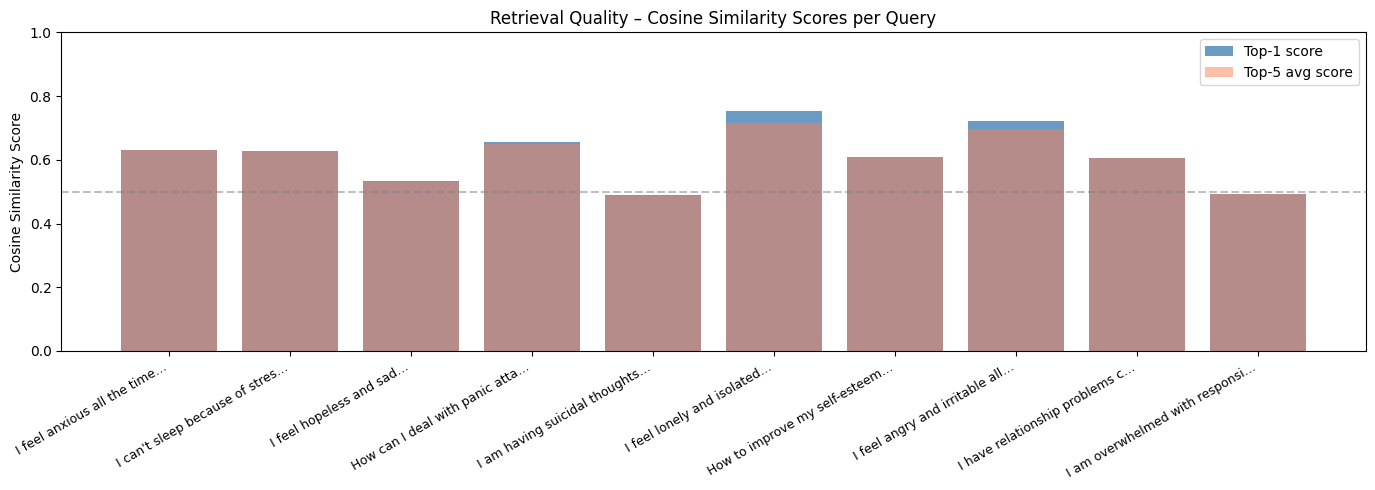

Mean Top-1 Score : 0.6114
Mean Top-5 Score : 0.6040


In [39]:
import matplotlib.pyplot as plt
import numpy as np

eval_queries = [
    "I feel anxious all the time",
    "I can't sleep because of stress",
    "I feel hopeless and sad",
    "How can I deal with panic attacks?",
    "I am having suicidal thoughts",
    "I feel lonely and isolated",
    "How to improve my self-esteem",
    "I feel angry and irritable all the time",
    "I have relationship problems causing me stress",
    "I am overwhelmed with responsibilities",
]

top1_scores, top5_avg_scores = [], []

for query in eval_queries:
    results = retrieve(query, top_k=5)
    scores  = [r["score"] for r in results]
    top1_scores.append(scores[0])
    top5_avg_scores.append(np.mean(scores))

# ── Plot ─────────────────────────────────────────────────────────────────
x = range(len(eval_queries))
labels = [q[:30] + "…" for q in eval_queries]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x, top1_scores,     label="Top-1 score",      alpha=0.8, color="steelblue")
ax.bar(x, top5_avg_scores, label="Top-5 avg score",  alpha=0.5, color="coral")
ax.set_xticks(list(x))
ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Cosine Similarity Score")
ax.set_title("Retrieval Quality – Cosine Similarity Scores per Query")
ax.legend()
ax.set_ylim(0, 1)
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="0.5 threshold")
plt.tight_layout()
plt.savefig("retrieval_quality.png", dpi=120)
plt.show()

print(f"Mean Top-1 Score : {np.mean(top1_scores):.4f}")
print(f"Mean Top-5 Score : {np.mean(top5_avg_scores):.4f}")

---
## 8. Save Pipeline Artefacts

In [40]:
import json

# Save pipeline configuration for deployment
config = {
    "collection_name":  COLLECTION_NAME,
    "embedding_model":  EMBEDDING_MODEL,
    "gemini_model":    GEMINI_MODEL,
    "top_k":            TOP_K,
    "vector_dim":       VECTOR_DIM,
    "total_documents":  qdrant.count(COLLECTION_NAME).count,
}

with open("pipeline_config.json", "w") as f:
    json.dump(config, f, indent=2)

print("✅ pipeline_config.json saved:")
print(json.dumps(config, indent=2))

✅ pipeline_config.json saved:
{
  "collection_name": "mental_health_kb",
  "embedding_model": "sentence-transformers/all-MiniLM-L6-v2",
  "gemini_model": "gemini-3.5-flash",
  "top_k": 5,
  "vector_dim": 384,
  "total_documents": 3504
}


---
## 9. Summary & Next Steps

### What was built in Module 4

| Component | Technology | Role |
|-----------|-----------|------|
| Data Loading | Hugging Face `datasets` | Load & pre-process counselling conversations |
| Embeddings | `sentence-transformers/all-MiniLM-L6-v2` | 384-dim dense vectors for semantic search |
| Vector Store | Qdrant Cloud (free tier) | Store & retrieve vectors by cosine similarity |
| LLM | Google Gemini `gemini-3.5-flash` | Generate empathetic, grounded answers |
| RAG Pipeline | Custom Python | Orchestrate Retrieve → Augment → Generate |

### Integration with other modules

```
User Query
    │
    ├── Module 1 (Language Detection) ──→ detect language → route to right KB
    ├── Module 2 (Emotion Classifier) ──→ detect emotion → tune system prompt
    ├── Module 3 (Intent Classifier)  ──→ intent = asking_mental_health_question ?
    │                                         Yes → Module 4 (RAG)
    │                                         No  → direct reply
    └── Module 4 (RAG) ───────────────→ retrieve + generate final answer
```

### Deployment
Run `uvicorn app:app --reload` to start the FastAPI server.
Call `POST /chat` with `{"query": "..."}` to get answers.
Visit `http://localhost:8000/docs` for the Swagger UI.